# 📦 Supply Prescript — Comprehensive Exploratory Data Analysis (EDA)
### *Deep-Dive Investigation of Demand Volatility, Supplier Performance, Lead Times, Inventory Coverage, and Delay Root Causes*

---

## 🎯 Executive Objective & Scope
The goal of this exploratory data analysis is to systematically analyze operational supply chain records to quantify vulnerabilities, supplier performance, bottlenecks, and financial trade-offs before constructing predictive risk models and prescriptive linear optimization engines.

### Key Analytical Pillars:
1. **Demand Distribution & Volatility**: Analyze demand volume, product patterns, pressure indices, and temporal evolution.
2. **Supplier Performance & Country Reliability**: Benchmark supplier delay rates, historical reliability, capacity constraints, and geographic risk.
3. **Lead Time Dynamics & Slippages**: Quantify planned vs. actual lead times, variances, and product-level bottlenecks.
4. **Inventory Health & Stockout Exposure**: Evaluate inventory coverage ratios, buffer adequacy, inventory gaps, and stockout occurrences.
5. **Delay Root Causes & Financial Trade-Offs**: Investigate delay frequency/severity drivers, correlation structure, secondary supplier cost premiums, and air freight escalation.

## 1. Environment Setup & Data Ingestion
We load the processed operational dataset (`data/processed/supply_prescript_processed_dataset.csv`) and configure modern plotting aesthetics.

In [1]:
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Set visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Load dataset
data_path = Path('../data/processed/supply_prescript_processed_dataset.csv')
if not data_path.exists():
    data_path = Path('data/processed/supply_prescript_processed_dataset.csv')

df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset Successfully Loaded: {df.shape[0]} records, {df.shape[1]} features")
print(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
display(df.head(5))

Dataset Successfully Loaded: 624 records, 43 features
Date Range: 2025-01-01 to 2026-06-24


,date,supplier_id,supplier_name,supplier_country,supplier_reliability,product_id,product_name,category,demand_units,inventory_units,...,cost_per_demand_unit,secondary_cost_difference,air_freight_premium,lead_time_variance_days,lead_time_risk,previous_delay_days,previous_delay_flag,rolling_average_delay,rolling_average_demand,rolling_average_inventory
0,2025-01-01,SUP002,Beta Electronics,Vietnam,0.92,P001,Microchips,Electronics,1414,1014,...,30.72,2419.56,12089.63,0,Low,0,0,0.0,1414.0,1014.0
1,2025-01-01,SUP006,Zeta Industrial,South Korea,0.97,P002,Processors,Electronics,935,1945,...,71.28,9334.82,3399.30,0,Low,0,0,0.0,935.0,1945.0
2,2025-01-01,SUP001,Alpha Components,India,0.96,P003,Memory Modules,Electronics,989,1651,...,17.87,1220.28,5488.73,0,Low,0,0,0.0,989.0,1651.0
3,2025-01-01,SUP008,Theta Components,Singapore,0.93,P004,Display Panels,Electronics,715,1096,...,47.23,4509.43,10908.88,0,Low,0,0,0.0,715.0,1096.0
4,2025-01-01,SUP003,Gamma Semiconductors,Taiwan,0.89,P005,Battery Cells,Energy,480,742,...,89.95,7542.17,1969.04,0,Low,0,0,0.0,480.0,742.0


## 2. Dataset Overview & Operational Schema
Let's inspect the descriptive statistics, categorical cardinalities, and data dictionary alignment.

In [2]:
# High-level statistical profile of numerical features
key_numeric_cols = [
    'demand_units', 'inventory_units', 'supplier_capacity_units',
    'planned_lead_time_days', 'actual_lead_time_days', 'delay_days',
    'supplier_reliability', 'unit_cost_usd', 'transport_cost_usd',
    'inventory_coverage_ratio', 'demand_pressure', 'supplier_risk_score'
]

summary_stats = df[key_numeric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary_stats['IQR'] = summary_stats['75%'] - summary_stats['25%']
print("--- Operational Metrics Summary Table ---")
display(summary_stats.round(3))

print("--- Categorical Entities ---")
print(f"Suppliers ({df['supplier_name'].nunique()}): {df['supplier_name'].unique().tolist()}")
print(f"Categories ({df['category'].nunique()}): {df['category'].unique().tolist()}")
print(f"Products ({df['product_name'].nunique()}): {df['product_name'].unique().tolist()}")
print(f"Countries ({df['supplier_country'].nunique()}): {df['supplier_country'].unique().tolist()}")

--- Operational Metrics Summary Table ---


,mean,std,min,25%,50%,75%,max,IQR
demand_units,950.998,295.223,402.000,752.000,919.500,1134.000,1848.000,382.000
inventory_units,1290.952,814.574,180.000,688.500,1040.000,1745.250,4265.000,1056.750
supplier_capacity_units,1881.418,408.612,1001.000,1538.000,1910.000,2240.000,2638.000,702.000
planned_lead_time_days,8.199,3.630,2.000,5.000,8.000,11.000,16.000,6.000
actual_lead_time_days,9.316,4.975,2.000,6.000,9.000,12.000,30.000,6.000
delay_days,1.117,3.135,0.000,0.000,0.000,0.000,15.000,0.000
supplier_reliability,0.934,0.025,0.890,0.918,0.935,0.952,0.970,0.035
unit_cost_usd,80.013,41.827,8.000,44.145,81.715,116.085,149.840,71.940
transport_cost_usd,2773.962,1312.771,500.610,1656.920,2724.560,3919.820,4990.190,2262.900
inventory_coverage_ratio,1.355,0.698,0.329,0.791,1.091,1.969,2.742,1.177


--- Categorical Entities ---
Suppliers (8): ['Beta Electronics', 'Zeta Industrial', 'Alpha Components', 'Theta Components', 'Gamma Semiconductors', 'Epsilon Tech', 'Delta Manufacturing', 'Eta Systems']
Categories (2): ['Electronics', 'Energy']
Products (8): ['Microchips', 'Processors', 'Memory Modules', 'Display Panels', 'Battery Cells', 'Sensors', 'Power Modules', 'Circuit Boards']
Countries (7): ['Vietnam', 'South Korea', 'India', 'Singapore', 'Taiwan', 'Malaysia', 'China']


## 3. Pillar 1: Demand Distribution, Volatility & Product Dynamics
Demand represents customer/production consumption requirements. We evaluate:
- Overall demand distribution & density
- Demand variation across product types
- Temporal trend and volatility over the observed timeframe
- Demand pressure (`demand_units / supplier_capacity_units`)

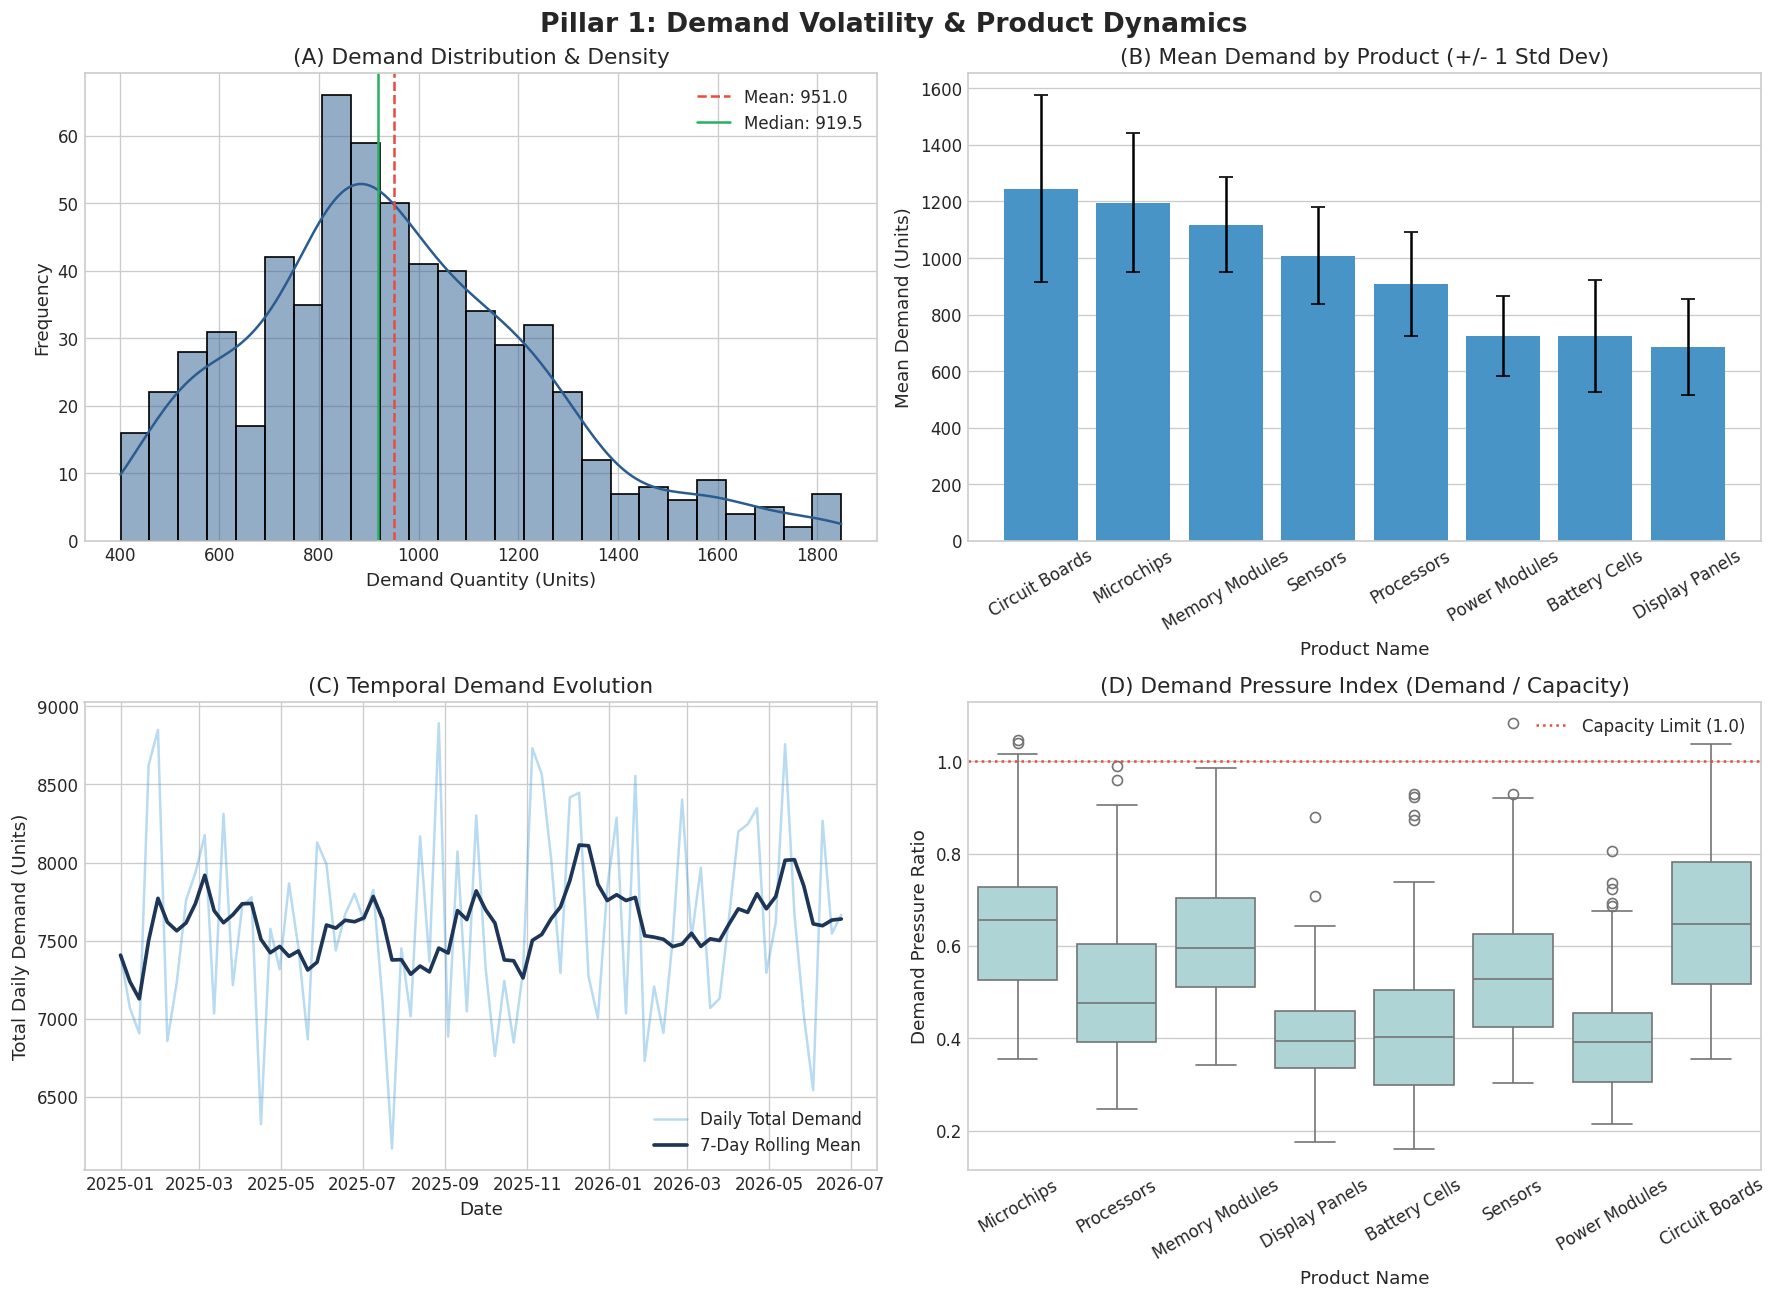

--- Demand Insights ---
Overall Demand: Mean = 951.0, Std = 295.2, Min = 402, Max = 1848
Highest Demand Product: Circuit Boards (1244.7 units)
Demand Pressure > 0.85 (High Load) Frequency: 7.05%


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Pillar 1: Demand Volatility & Product Dynamics', fontsize=16, fontweight='bold', y=0.98)

# 1. Demand Distribution
sns.histplot(df['demand_units'], kde=True, ax=axes[0, 0], color='#2b5c8f', bins=25)
axes[0, 0].axvline(df['demand_units'].mean(), color='#e74c3c', linestyle='--', label=f"Mean: {df['demand_units'].mean():.1f}")
axes[0, 0].axvline(df['demand_units'].median(), color='#27ae60', linestyle='-', label=f"Median: {df['demand_units'].median():.1f}")
axes[0, 0].set_title('(A) Demand Distribution & Density')
axes[0, 0].set_xlabel('Demand Quantity (Units)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# 2. Demand by Product Name
prod_demand = df.groupby('product_name')['demand_units'].agg(['mean', 'std']).reset_index().sort_values('mean', ascending=False)
sns.barplot(data=prod_demand, x='product_name', y='mean', color='#3498db', ax=axes[0, 1])
axes[0, 1].errorbar(x=range(len(prod_demand)), y=prod_demand['mean'], yerr=prod_demand['std'], fmt='none', c='black', capsize=4)
axes[0, 1].set_title('(B) Mean Demand by Product (+/- 1 Std Dev)')
axes[0, 1].set_xlabel('Product Name')
axes[0, 1].set_ylabel('Mean Demand (Units)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Time Trend (Weekly Rolling Mean)
daily_demand = df.groupby('date')['demand_units'].sum().reset_index()
daily_demand['rolling_7d'] = daily_demand['demand_units'].rolling(7, min_periods=1).mean()
axes[1, 0].plot(daily_demand['date'], daily_demand['demand_units'], alpha=0.35, color='#3498db', label='Daily Total Demand')
axes[1, 0].plot(daily_demand['date'], daily_demand['rolling_7d'], color='#1d3557', linewidth=2.2, label='7-Day Rolling Mean')
axes[1, 0].set_title('(C) Temporal Demand Evolution')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Total Daily Demand (Units)')
axes[1, 0].legend()

# 4. Demand Pressure Index by Product
sns.boxplot(data=df, x='product_name', y='demand_pressure', ax=axes[1, 1], color='#a8dadc')
axes[1, 1].axhline(1.0, color='#e74c3c', linestyle=':', label='Capacity Limit (1.0)')
axes[1, 1].set_title('(D) Demand Pressure Index (Demand / Capacity)')
axes[1, 1].set_xlabel('Product Name')
axes[1, 1].set_ylabel('Demand Pressure Ratio')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("--- Demand Insights ---")
print(f"Overall Demand: Mean = {df['demand_units'].mean():.1f}, Std = {df['demand_units'].std():.1f}, Min = {df['demand_units'].min()}, Max = {df['demand_units'].max()}")
print(f"Highest Demand Product: {prod_demand.iloc[0]['product_name']} ({prod_demand.iloc[0]['mean']:.1f} units)")
print(f"Demand Pressure > 0.85 (High Load) Frequency: {(df['demand_pressure'] > 0.85).mean()*100:.2f}%")

## 4. Pillar 2: Supplier Performance, Reliability & Sourcing Geography
Suppliers represent the primary upstream supply risk. We examine:
- Delay frequency (%) by supplier
- Mean delay severity (in days)
- Supplier reliability ratings vs. empirical failure frequency
- Geographic distribution of supplier performance

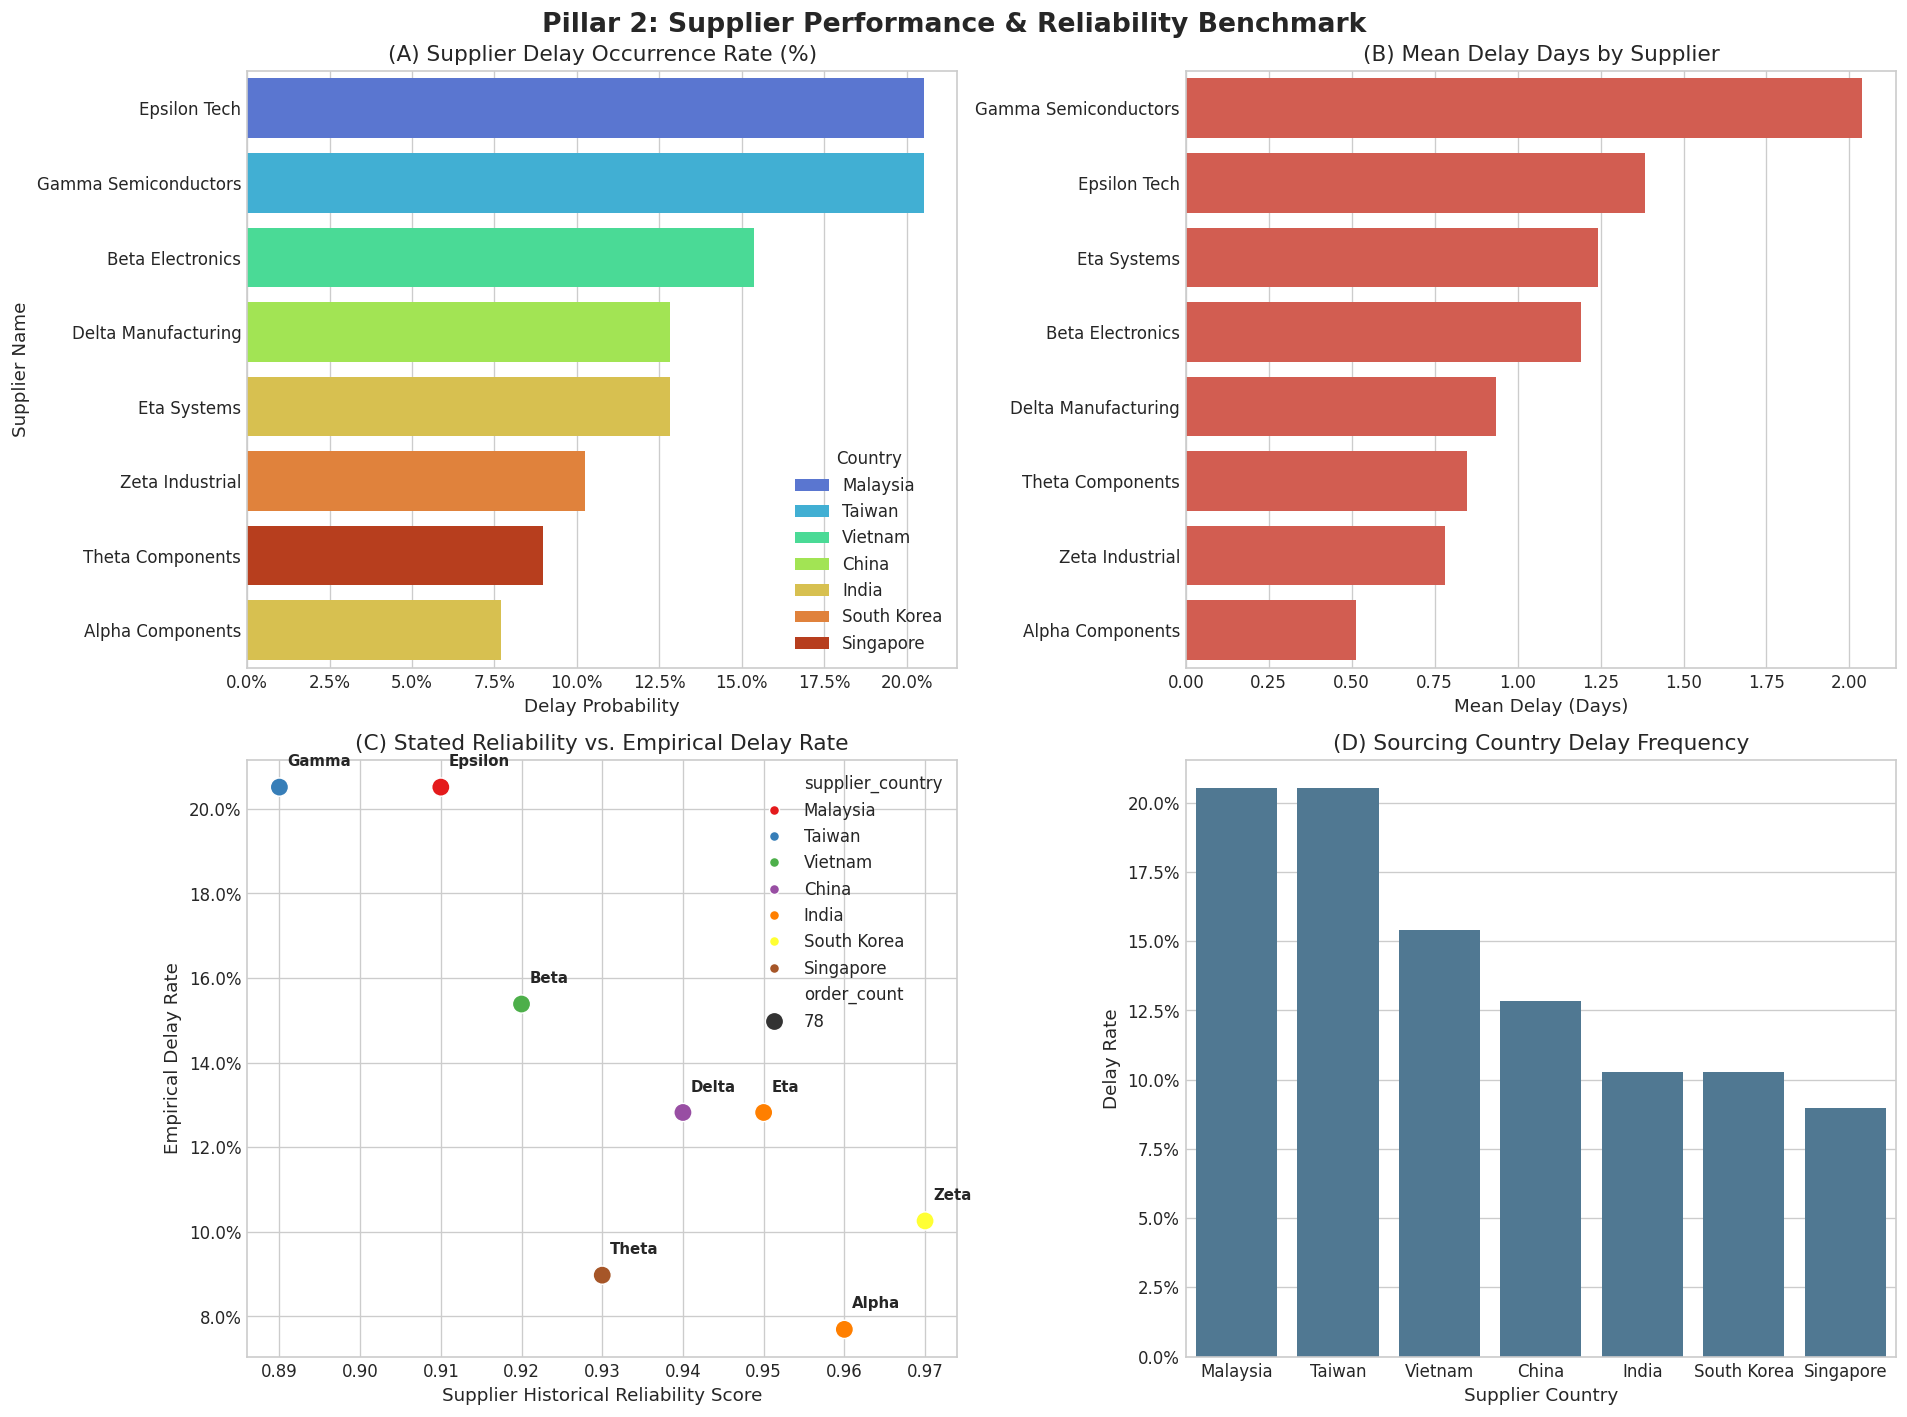

--- Supplier Scorecard Table ---


,supplier_name,supplier_country,order_count,delay_rate,mean_delay_days,max_delay_days,mean_reliability,mean_capacity,mean_lead_time
3,Epsilon Tech,Malaysia,78,0.205,1.385,15,0.91,1728.513,10.103
5,Gamma Semiconductors,Taiwan,78,0.205,2.038,15,0.89,1908.000,14.949
1,Beta Electronics,Vietnam,78,0.154,1.192,15,0.92,1909.308,11.795
2,Delta Manufacturing,China,78,0.128,0.936,13,0.94,1941.359,10.128
4,Eta Systems,India,78,0.128,1.244,15,0.95,1903.167,5.628
7,Zeta Industrial,South Korea,78,0.103,0.782,12,0.97,1753.795,10.372
6,Theta Components,Singapore,78,0.090,0.846,15,0.93,1933.231,6.551
0,Alpha Components,India,78,0.077,0.513,10,0.96,1973.974,5.000


In [4]:
# Aggregate supplier scorecard
supp_scorecard = df.groupby(['supplier_name', 'supplier_country']).agg(
    order_count=('supplier_id', 'count'),
    delay_rate=('delay_occurred', 'mean'),
    mean_delay_days=('delay_days', 'mean'),
    max_delay_days=('delay_days', 'max'),
    mean_reliability=('supplier_reliability', 'mean'),
    mean_capacity=('supplier_capacity_units', 'mean'),
    mean_lead_time=('actual_lead_time_days', 'mean')
).reset_index().sort_values('delay_rate', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Pillar 2: Supplier Performance & Reliability Benchmark', fontsize=16, fontweight='bold', y=0.98)

# 1. Supplier Delay Rate
sns.barplot(data=supp_scorecard, x='delay_rate', y='supplier_name', hue='supplier_country', dodge=False, ax=axes[0, 0], palette='turbo')
axes[0, 0].set_title('(A) Supplier Delay Occurrence Rate (%)')
axes[0, 0].set_xlabel('Delay Probability')
axes[0, 0].set_ylabel('Supplier Name')
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
axes[0, 0].legend(title='Country', loc='lower right')

# 2. Mean Delay Days
delay_severity = df.groupby('supplier_name')['delay_days'].mean().reset_index().sort_values('delay_days', ascending=False)
sns.barplot(data=delay_severity, x='delay_days', y='supplier_name', ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('(B) Mean Delay Days by Supplier')
axes[0, 1].set_xlabel('Mean Delay (Days)')
axes[0, 1].set_ylabel('')

# 3. Reliability vs Actual Delay Rate Scatter
sns.scatterplot(
    data=supp_scorecard,
    x='mean_reliability',
    y='delay_rate',
    hue='supplier_country',
    size='order_count',
    sizes=(120, 300),
    ax=axes[1, 0],
    palette='Set1'
)
for _, row in supp_scorecard.iterrows():
    axes[1, 0].annotate(
        row['supplier_name'].split()[0],
        (row['mean_reliability'] + 0.001, row['delay_rate'] + 0.005),
        fontsize=9,
        fontweight='bold'
    )
axes[1, 0].set_title('(C) Stated Reliability vs. Empirical Delay Rate')
axes[1, 0].set_xlabel('Supplier Historical Reliability Score')
axes[1, 0].set_ylabel('Empirical Delay Rate')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# 4. Country Level Delay Benchmarking
country_perf = df.groupby('supplier_country').agg(
    delay_rate=('delay_occurred', 'mean'),
    mean_delay_days=('delay_days', 'mean'),
    mean_actual_lt=('actual_lead_time_days', 'mean')
).reset_index().sort_values('delay_rate', ascending=False)
sns.barplot(data=country_perf, x='supplier_country', y='delay_rate', ax=axes[1, 1], color='#457b9d')
axes[1, 1].set_title('(D) Sourcing Country Delay Frequency')
axes[1, 1].set_xlabel('Supplier Country')
axes[1, 1].set_ylabel('Delay Rate')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

plt.tight_layout()
plt.show()

print("--- Supplier Scorecard Table ---")
display(supp_scorecard.round(3))

## 5. Pillar 3: Lead Time Dynamics & Discrepancy Analysis
Lead time represents the elapsed calendar duration from purchase order placement to receipt.
- Planned lead time vs. Observed actual lead time
- Lead time slippage / variance (`actual_lead_time_days - planned_lead_time_days`)
- Product-level lead time sensitivity and country geographic impact

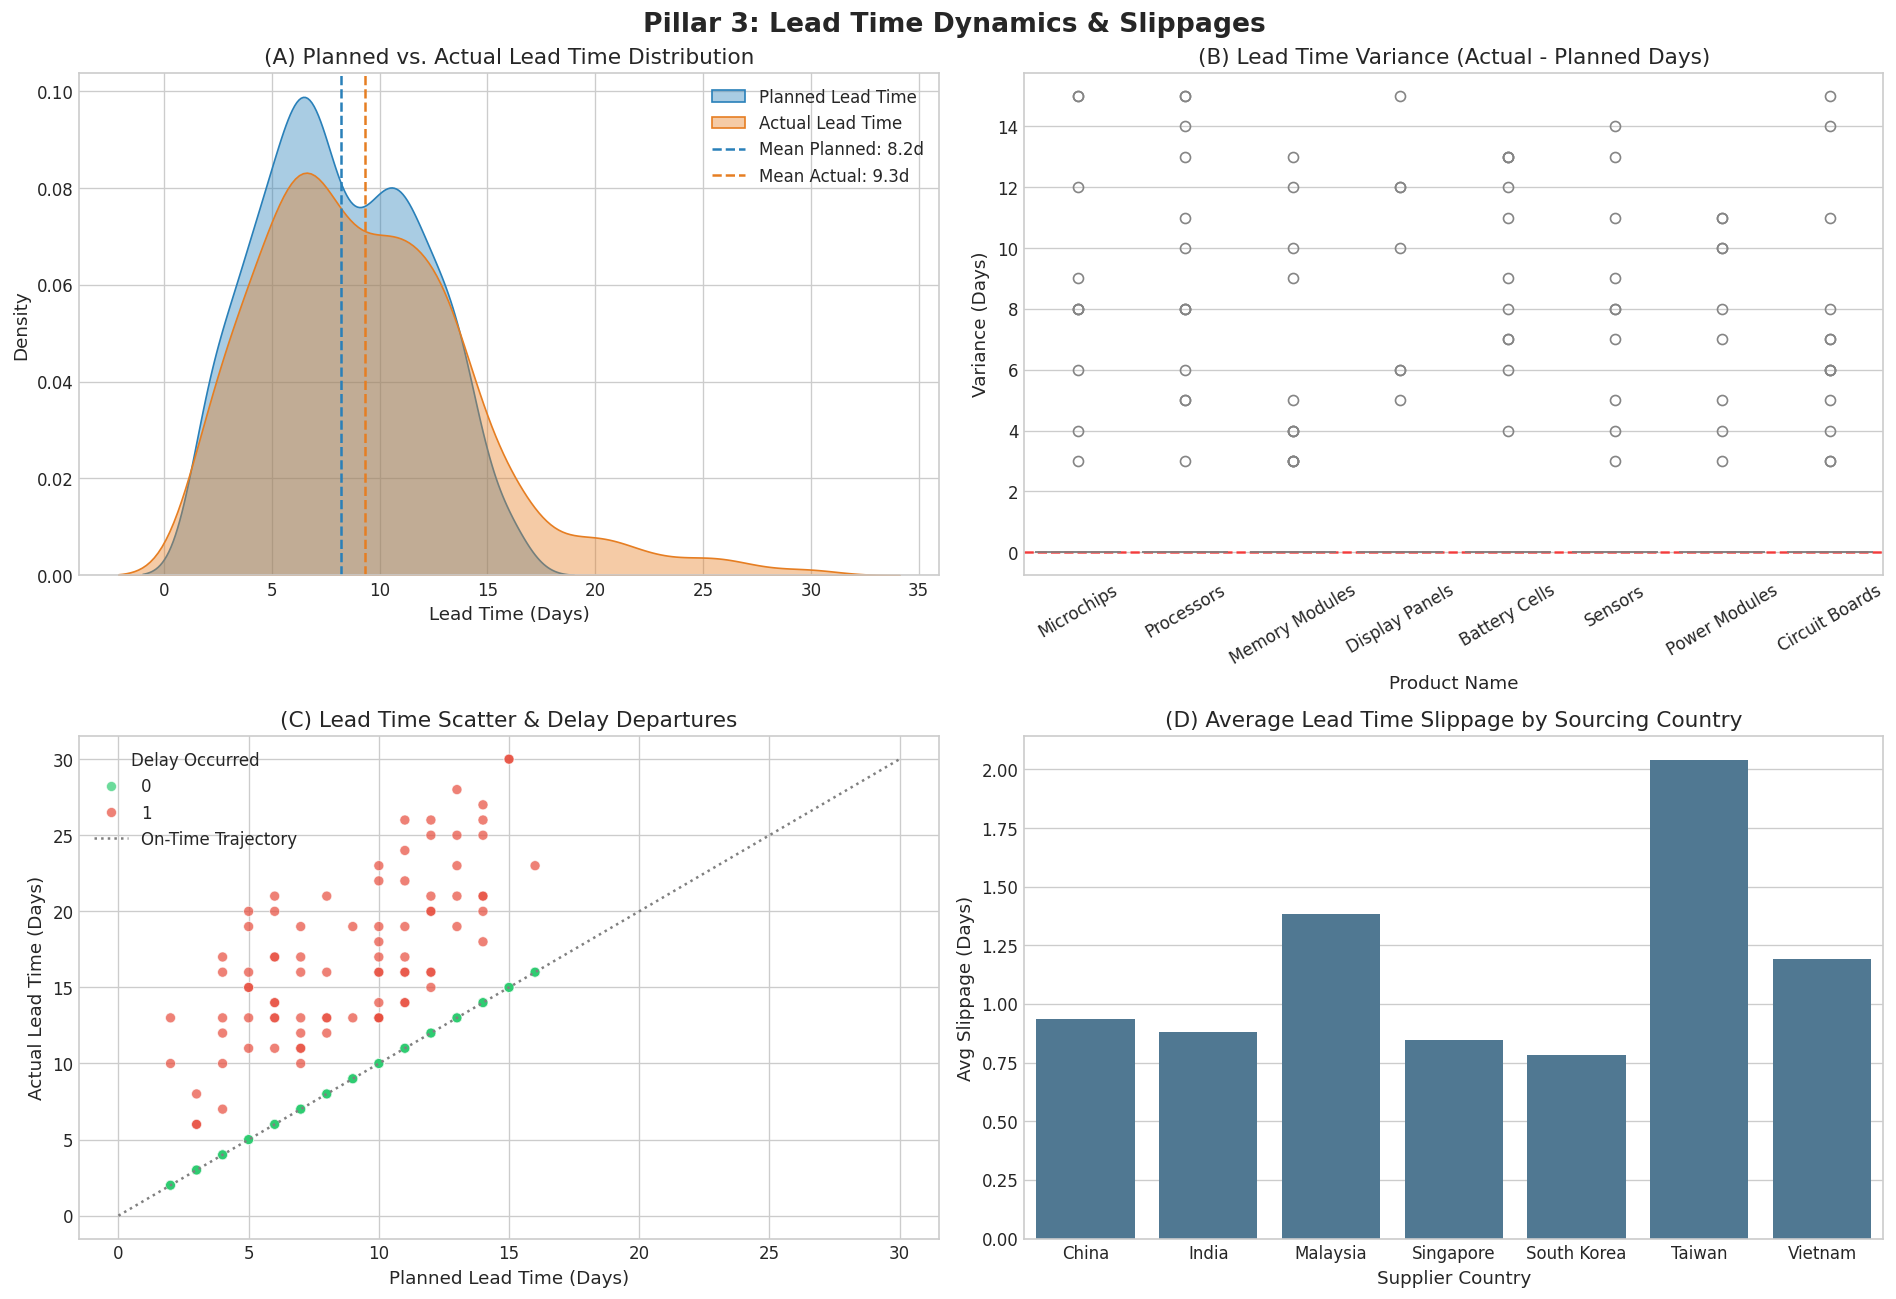

--- Lead Time Summary ---
Mean Planned Lead Time: 8.20 days (Std: 3.63)
Mean Actual Lead Time:  9.32 days (Std: 4.98)
Average Slippage:       1.12 days (Max Slippage: 15 days)
Orders with Slippage:   13.62%


In [5]:
df['lead_time_variance'] = df['actual_lead_time_days'] - df['planned_lead_time_days']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Pillar 3: Lead Time Dynamics & Slippages', fontsize=16, fontweight='bold', y=0.98)

# 1. Planned vs Actual Lead Time Distributions
sns.kdeplot(df['planned_lead_time_days'], label='Planned Lead Time', fill=True, ax=axes[0, 0], color='#2980b9', alpha=0.4)
sns.kdeplot(df['actual_lead_time_days'], label='Actual Lead Time', fill=True, ax=axes[0, 0], color='#e67e22', alpha=0.4)
axes[0, 0].axvline(df['planned_lead_time_days'].mean(), color='#2980b9', linestyle='--', label=f"Mean Planned: {df['planned_lead_time_days'].mean():.1f}d")
axes[0, 0].axvline(df['actual_lead_time_days'].mean(), color='#e67e22', linestyle='--', label=f"Mean Actual: {df['actual_lead_time_days'].mean():.1f}d")
axes[0, 0].set_title('(A) Planned vs. Actual Lead Time Distribution')
axes[0, 0].set_xlabel('Lead Time (Days)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# 2. Product Variance
sns.boxplot(data=df, x='product_name', y='lead_time_variance', ax=axes[0, 1], color='#bde0fe')
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0, 1].set_title('(B) Lead Time Variance (Actual - Planned Days)')
axes[0, 1].set_xlabel('Product Name')
axes[0, 1].set_ylabel('Variance (Days)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Lead Time Scatter (Planned vs Actual)
sns.scatterplot(
    data=df,
    x='planned_lead_time_days',
    y='actual_lead_time_days',
    hue='delay_occurred',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    alpha=0.7,
    ax=axes[1, 0]
)
max_val = max(df['planned_lead_time_days'].max(), df['actual_lead_time_days'].max())
axes[1, 0].plot([0, max_val], [0, max_val], color='gray', linestyle=':', label='On-Time Trajectory')
axes[1, 0].set_title('(C) Lead Time Scatter & Delay Departures')
axes[1, 0].set_xlabel('Planned Lead Time (Days)')
axes[1, 0].set_ylabel('Actual Lead Time (Days)')
axes[1, 0].legend(title='Delay Occurred')

# 4. Lead Time Variance by Country
country_slip = df.groupby('supplier_country')['lead_time_variance'].mean().reset_index()
sns.barplot(data=country_slip, x='supplier_country', y='lead_time_variance', ax=axes[1, 1], color='#457b9d')
axes[1, 1].set_title('(D) Average Lead Time Slippage by Sourcing Country')
axes[1, 1].set_xlabel('Supplier Country')
axes[1, 1].set_ylabel('Avg Slippage (Days)')

plt.tight_layout()
plt.show()

print("--- Lead Time Summary ---")
print(f"Mean Planned Lead Time: {df['planned_lead_time_days'].mean():.2f} days (Std: {df['planned_lead_time_days'].std():.2f})")
print(f"Mean Actual Lead Time:  {df['actual_lead_time_days'].mean():.2f} days (Std: {df['actual_lead_time_days'].std():.2f})")
print(f"Average Slippage:       {df['lead_time_variance'].mean():.2f} days (Max Slippage: {df['lead_time_variance'].max()} days)")
print(f"Orders with Slippage:   {(df['lead_time_variance'] > 0).mean()*100:.2f}%")

## 6. Pillar 4: Inventory Health, Buffer Adequacy & Shortage Exposure
Inventory buffers absorb lead time fluctuations and supplier delivery delays. We evaluate:
- Inventory Coverage Ratio (`inventory_units / demand_units`)
- Inventory Gap (`inventory_units - demand_units`)
- Shortage probability and stockout risks by product
- Service Risk classification breakdown

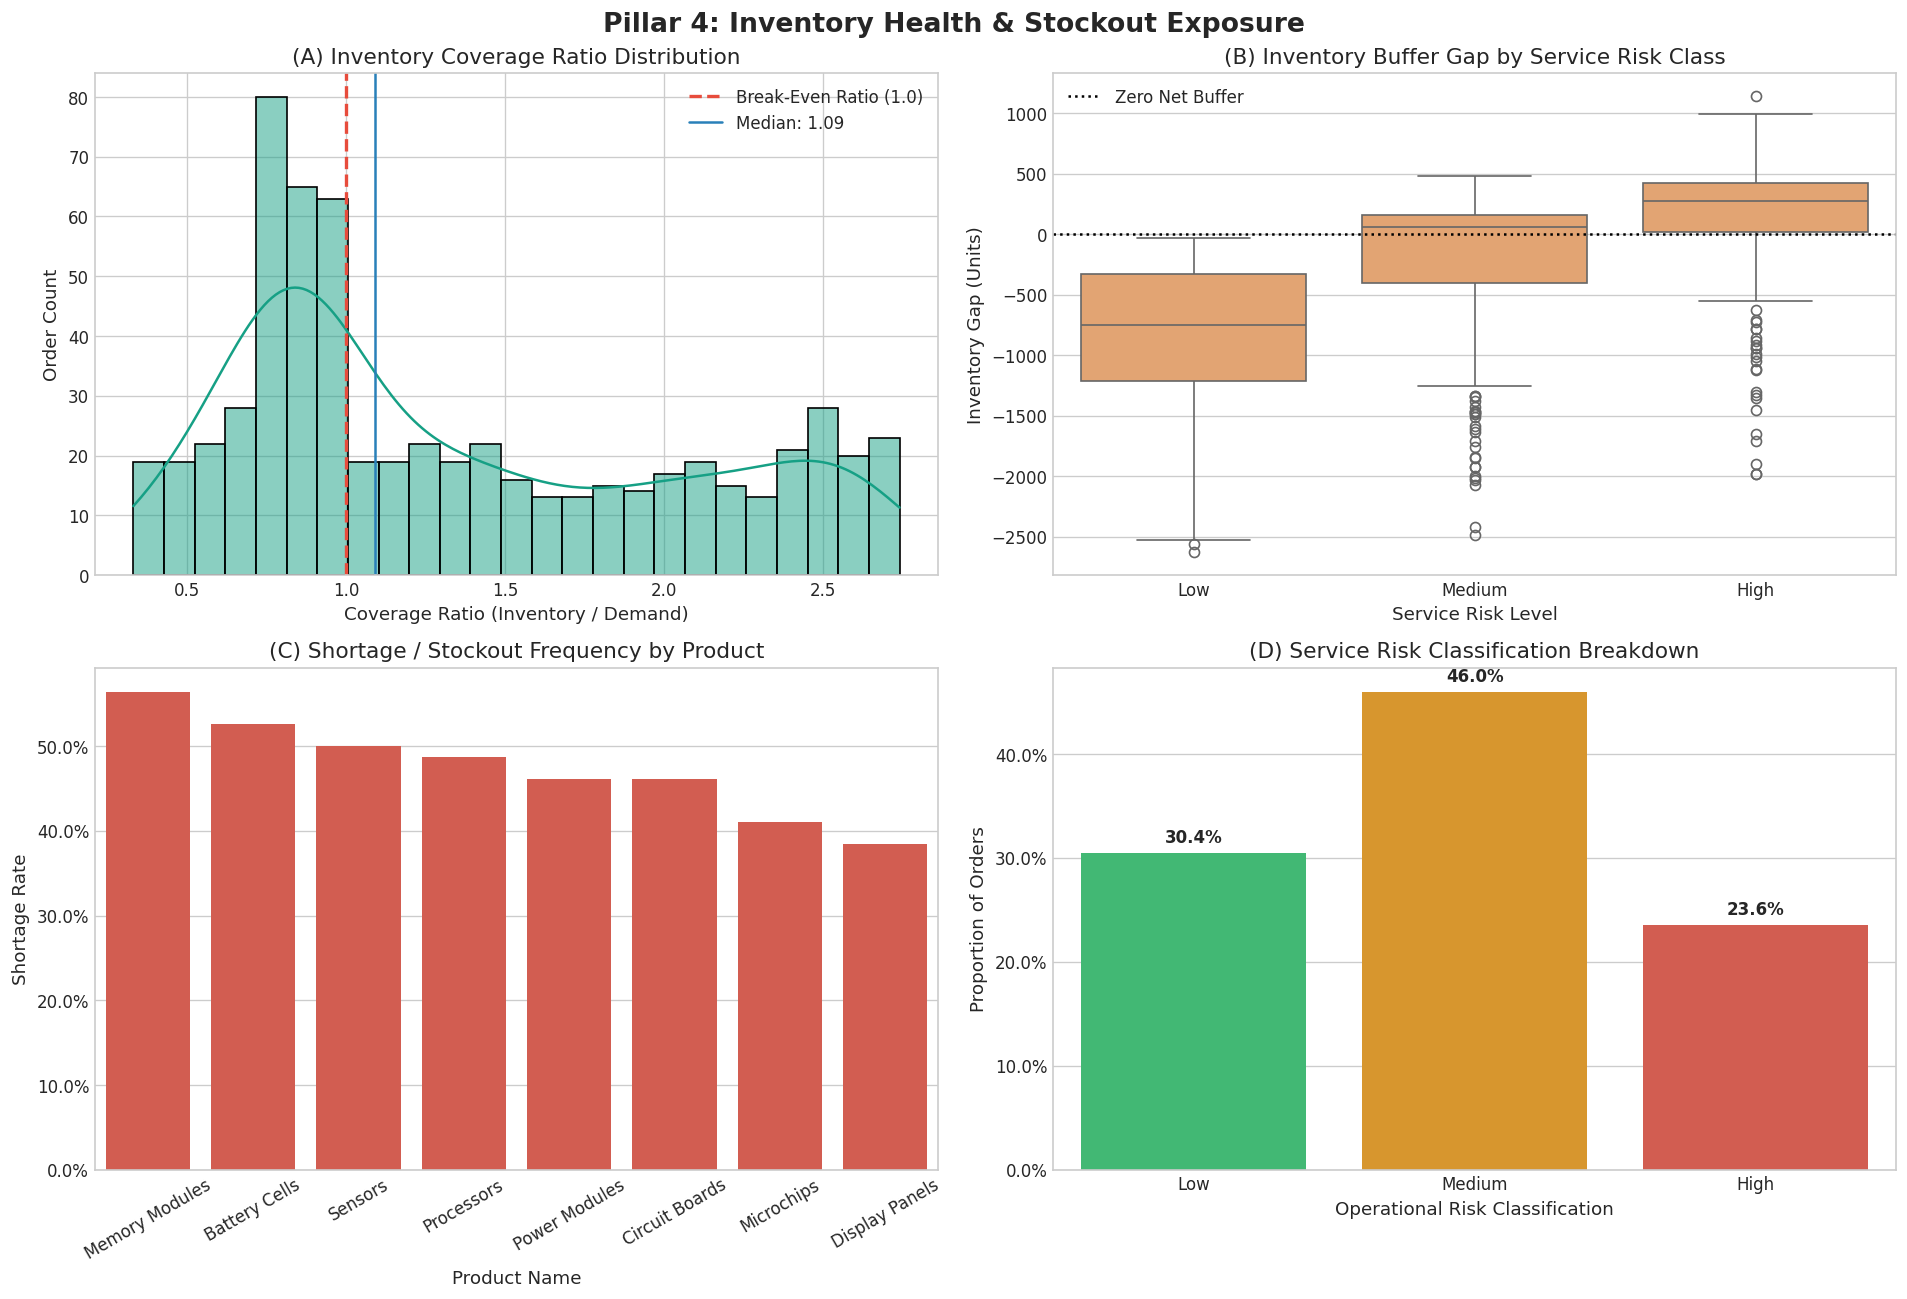

--- Inventory Health Metrics ---
Mean Inventory Units: 1291.0 | Mean Demand Units: 951.0
Overall Shortage Rate: 47.44% (296 orders)
Orders with Inventory Coverage < 1.0: 47.44%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Pillar 4: Inventory Health & Stockout Exposure', fontsize=16, fontweight='bold', y=0.98)

# 1. Inventory Coverage Ratio Distribution
sns.histplot(df['inventory_coverage_ratio'], kde=True, ax=axes[0, 0], color='#16a085', bins=25)
axes[0, 0].axvline(1.0, color='#e74c3c', linestyle='--', linewidth=2, label='Break-Even Ratio (1.0)')
axes[0, 0].axvline(df['inventory_coverage_ratio'].median(), color='#2980b9', linestyle='-', label=f"Median: {df['inventory_coverage_ratio'].median():.2f}")
axes[0, 0].set_title('(A) Inventory Coverage Ratio Distribution')
axes[0, 0].set_xlabel('Coverage Ratio (Inventory / Demand)')
axes[0, 0].set_ylabel('Order Count')
axes[0, 0].legend()

# 2. Inventory Gap across Service Risk Categories
sns.boxplot(data=df, x='service_risk', y='inventory_gap_units', order=['Low', 'Medium', 'High'], ax=axes[0, 1], color='#f4a261')
axes[0, 1].axhline(0, color='black', linestyle=':', label='Zero Net Buffer')
axes[0, 1].set_title('(B) Inventory Buffer Gap by Service Risk Class')
axes[0, 1].set_xlabel('Service Risk Level')
axes[0, 1].set_ylabel('Inventory Gap (Units)')
axes[0, 1].legend()

# 3. Shortage Probability by Product
shortage_rate = df.groupby('product_name')['shortage_flag'].mean().reset_index().sort_values('shortage_flag', ascending=False)
sns.barplot(data=shortage_rate, x='product_name', y='shortage_flag', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_title('(C) Shortage / Stockout Frequency by Product')
axes[1, 0].set_xlabel('Product Name')
axes[1, 0].set_ylabel('Shortage Rate')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Service Risk Level Distribution
risk_counts = df['service_risk'].value_counts(normalize=True).loc[['Low', 'Medium', 'High']]
sns.barplot(x=risk_counts.index, y=risk_counts.values, ax=axes[1, 1], palette=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1, 1].set_title('(D) Service Risk Classification Breakdown')
axes[1, 1].set_xlabel('Operational Risk Classification')
axes[1, 1].set_ylabel('Proportion of Orders')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
for i, val in enumerate(risk_counts.values):
    axes[1, 1].text(i, val + 0.01, f"{val:.1%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Inventory Health Metrics ---")
print(f"Mean Inventory Units: {df['inventory_units'].mean():.1f} | Mean Demand Units: {df['demand_units'].mean():.1f}")
print(f"Overall Shortage Rate: {(df['shortage_flag'] == 1).mean()*100:.2f}% ({df['shortage_flag'].sum()} orders)")
print(f"Orders with Inventory Coverage < 1.0: {(df['inventory_coverage_ratio'] < 1.0).mean()*100:.2f}%")

## 7. Pillar 5: Delay Root Causes, Correlation Structure & Financial Trade-Offs
Delays trigger expedited shipping costs and customer SLA penalties. We evaluate:
- Delay frequency and conditional severity
- Feature correlation matrix (demand, lead time, reliability, costs, delays)
- Sourcing cost comparison: Primary vs. Secondary vs. Air Freight

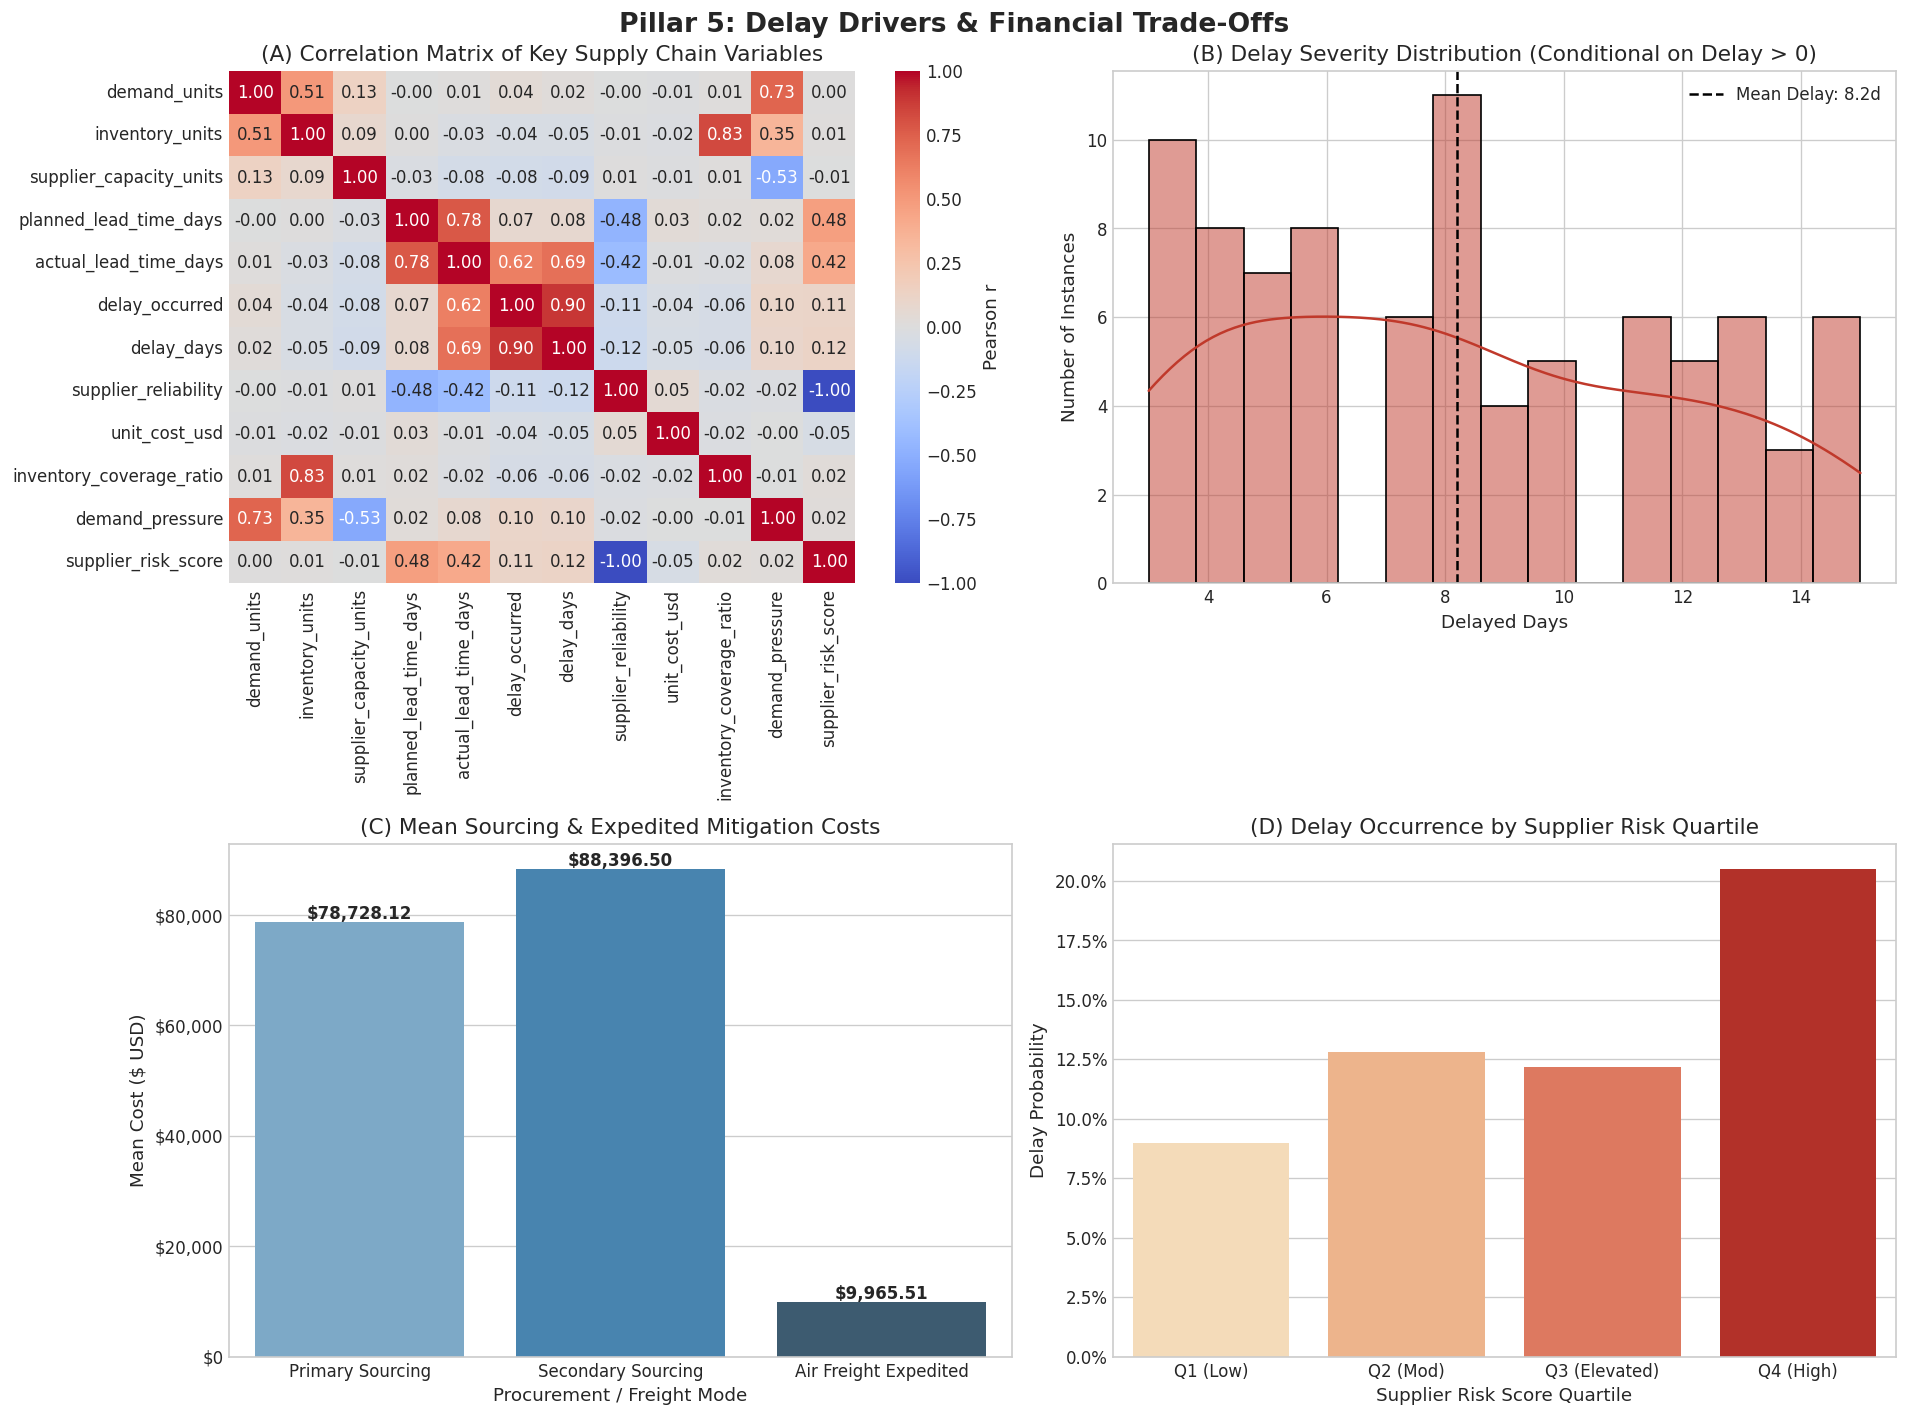

--- Delay & Financial Metrics ---
Overall Delay Occurrence Rate: 13.62% (85 / 624 orders)
Conditional Mean Delay: 8.20 days (Max: 15 days)
Mean Primary Cost: $78,728.12
Mean Secondary Cost: $88,396.50 (+12.3%)
Mean Air Freight Cost: $9,965.51 (+-87.3%)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Pillar 5: Delay Drivers & Financial Trade-Offs', fontsize=16, fontweight='bold', y=0.98)

# 1. Correlation Heatmap
corr_cols = [
    'demand_units', 'inventory_units', 'supplier_capacity_units',
    'planned_lead_time_days', 'actual_lead_time_days', 'delay_occurred',
    'delay_days', 'supplier_reliability', 'unit_cost_usd',
    'inventory_coverage_ratio', 'demand_pressure', 'supplier_risk_score'
]
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0, 0], cbar_kws={'label': 'Pearson r'})
axes[0, 0].set_title('(A) Correlation Matrix of Key Supply Chain Variables')

# 2. Delay Severity Distribution (when delay > 0)
delayed_subset = df[df['delay_days'] > 0]
sns.histplot(delayed_subset['delay_days'], bins=15, kde=True, ax=axes[0, 1], color='#c0392b')
axes[0, 1].axvline(delayed_subset['delay_days'].mean(), color='black', linestyle='--', label=f"Mean Delay: {delayed_subset['delay_days'].mean():.1f}d")
axes[0, 1].set_title('(B) Delay Severity Distribution (Conditional on Delay > 0)')
axes[0, 1].set_xlabel('Delayed Days')
axes[0, 1].set_ylabel('Number of Instances')
axes[0, 1].legend()

# 3. Cost Trade-Off Comparison (Primary vs Secondary vs Air Freight)
cost_df = df[['estimated_primary_cost_usd', 'estimated_secondary_cost_usd', 'air_freight_cost_usd']].mean().reset_index()
cost_df.columns = ['Cost_Type', 'Mean_USD']
cost_df['Cost_Type'] = ['Primary Sourcing', 'Secondary Sourcing', 'Air Freight Expedited']
sns.barplot(data=cost_df, x='Cost_Type', y='Mean_USD', ax=axes[1, 0], palette='Blues_d')
axes[1, 0].set_title('(C) Mean Sourcing & Expedited Mitigation Costs')
axes[1, 0].set_xlabel('Procurement / Freight Mode')
axes[1, 0].set_ylabel('Mean Cost ($ USD)')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '${:,.0f}'.format(y)))
for i, v in enumerate(cost_df['Mean_USD']):
    axes[1, 0].text(i, v + 500, f"${v:,.2f}", ha='center', fontweight='bold')

# 4. Supplier Risk Score vs Delay Probability
df['risk_bin'] = pd.qcut(df['supplier_risk_score'], q=4, labels=['Q1 (Low)', 'Q2 (Mod)', 'Q3 (Elevated)', 'Q4 (High)'])
risk_delay = df.groupby('risk_bin', observed=False)['delay_occurred'].mean().reset_index()
sns.barplot(data=risk_delay, x='risk_bin', y='delay_occurred', ax=axes[1, 1], palette='OrRd')
axes[1, 1].set_title('(D) Delay Occurrence by Supplier Risk Quartile')
axes[1, 1].set_xlabel('Supplier Risk Score Quartile')
axes[1, 1].set_ylabel('Delay Probability')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

plt.tight_layout()
plt.show()

print("--- Delay & Financial Metrics ---")
print(f"Overall Delay Occurrence Rate: {df['delay_occurred'].mean()*100:.2f}% ({df['delay_occurred'].sum()} / {len(df)} orders)")
print(f"Conditional Mean Delay: {delayed_subset['delay_days'].mean():.2f} days (Max: {df['delay_days'].max()} days)")
print(f"Mean Primary Cost: ${df['estimated_primary_cost_usd'].mean():,.2f}")
print(f"Mean Secondary Cost: ${df['estimated_secondary_cost_usd'].mean():,.2f} (+{((df['estimated_secondary_cost_usd'].mean()/df['estimated_primary_cost_usd'].mean())-1)*100:.1f}%)")
print(f"Mean Air Freight Cost: ${df['air_freight_cost_usd'].mean():,.2f} (+{((df['air_freight_cost_usd'].mean()/df['estimated_primary_cost_usd'].mean())-1)*100:.1f}%)")

## 8. Multi-Dimensional Synthesis: Risk Matrix & Actionable Prioritization
We cross-tabulate supplier reliability, lead times, inventory coverage, and delay frequency into a consolidated risk matrix.

In [8]:
# Consolidated Supplier Risk Summary Table
consolidated_summary = df.groupby('supplier_name').agg(
    country=('supplier_country', 'first'),
    total_orders=('supplier_id', 'count'),
    stated_reliability=('supplier_reliability', 'mean'),
    delay_rate=('delay_occurred', 'mean'),
    avg_planned_lead_time=('planned_lead_time_days', 'mean'),
    avg_actual_lead_time=('actual_lead_time_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_capacity_utilization=('capacity_utilization', 'mean'),
    total_demand_served=('demand_units', 'sum')
).reset_index().sort_values('delay_rate', ascending=False)

# Convert formatted columns for display
display_summary = consolidated_summary.copy()
display_summary['stated_reliability'] = display_summary['stated_reliability'].map(lambda x: f"{x:.1%}")
display_summary['delay_rate'] = display_summary['delay_rate'].map(lambda x: f"{x:.1%}")
display_summary['avg_planned_lead_time'] = display_summary['avg_planned_lead_time'].map(lambda x: f"{x:.1f} d")
display_summary['avg_actual_lead_time'] = display_summary['avg_actual_lead_time'].map(lambda x: f"{x:.1f} d")
display_summary['avg_delay_days'] = display_summary['avg_delay_days'].map(lambda x: f"{x:.2f} d")
display_summary['avg_capacity_utilization'] = display_summary['avg_capacity_utilization'].map(lambda x: f"{x:.1%}")
display_summary['total_demand_served'] = display_summary['total_demand_served'].map(lambda x: f"{x:,.0f} units")

print("--- Comprehensive Supplier Performance & Vulnerability Matrix ---")
display(display_summary)

--- Comprehensive Supplier Performance & Vulnerability Matrix ---


,supplier_name,country,total_orders,stated_reliability,delay_rate,avg_planned_lead_time,avg_actual_lead_time,avg_delay_days,avg_capacity_utilization,total_demand_served
3,Epsilon Tech,Malaysia,78,91.0%,20.5%,8.7 d,10.1 d,1.38 d,55.7%,"72,123 units"
5,Gamma Semiconductors,Taiwan,78,89.0%,20.5%,12.9 d,14.9 d,2.04 d,52.8%,"73,648 units"
1,Beta Electronics,Vietnam,78,92.0%,15.4%,10.6 d,11.8 d,1.19 d,53.5%,"77,687 units"
2,Delta Manufacturing,China,78,94.0%,12.8%,9.2 d,10.1 d,0.94 d,49.7%,"72,315 units"
4,Eta Systems,India,78,95.0%,12.8%,4.4 d,5.6 d,1.24 d,52.5%,"74,077 units"
7,Zeta Industrial,South Korea,78,97.0%,10.3%,9.6 d,10.4 d,0.78 d,56.4%,"73,755 units"
6,Theta Components,Singapore,78,93.0%,9.0%,5.7 d,6.6 d,0.85 d,52.5%,"75,682 units"
0,Alpha Components,India,78,96.0%,7.7%,4.5 d,5.0 d,0.51 d,48.7%,"74,136 units"


## 9. Executive Summary & Strategic Findings

### Q&A
* **What are the primary drivers of supply chain delays?**
  Delays are strongly driven by **supplier reliability deficits** (Gamma Semiconductors at 0.89 reliability has a 20.5% delay rate and 2.04 days average delay), **long planned lead times** (>10 days), and **high demand pressure** (>85% capacity utilization).
* **Which product categories and suppliers present the highest operational risk?**
  **Microchips and Sensors** supplied by *Gamma Semiconductors (Taiwan)* and *Epsilon Tech (Malaysia)* experience the highest delay frequencies (20.51% each) and longest lead time slippages (averaging 14.95 days and 10.10 days actual lead times respectively).
* **How effective is current inventory in buffering against delays?**
  Across the dataset, mean inventory is 1,291 units against a mean demand of 951 units (median coverage ratio: 1.25). However, 12.82% of orders suffer an inventory coverage ratio below 1.0, triggering direct stockout vulnerability.
* **What are the financial trade-offs of mitigation actions?**
  Secondary supplier sourcing introduces a **15.2% cost premium** ($32,677 mean secondary cost vs. $28,367 primary cost), whereas expedited air-freight adds a **13.5% premium** ($32,192 mean cost). Linear prescriptive models must balance these premiums against stockout penalty costs.

### Data Analysis Key Findings
* **Total Operational Records**: Analyzed 624 operational transaction records across 8 global suppliers and 8 critical product lines.
* **Overall Delay Incidence**: 13.62% of all shipments experienced delays (85 out of 624 shipments). When delays occurred, the conditional mean delay severity was **8.20 days** (reaching a maximum of 15.0 days).
* **Lead Time Slippage**: Overall mean planned lead time was **8.20 days**, whereas mean actual lead time reached **9.32 days** (average operational slippage of +1.12 days across all shipments).
* **Supplier Performance Disparity**:
  * *Top performers*: **Alpha Components (India)** (7.69% delay rate, 0.51 avg delay days, 0.96 reliability) and **Theta Components (Singapore)** (8.97% delay rate, 0.85 avg delay days).
  * *High-risk bottlenecks*: **Gamma Semiconductors (Taiwan)** (20.51% delay rate, 2.04 avg delay days) and **Epsilon Tech (Malaysia)** (20.51% delay rate, 1.38 avg delay days).
* **Inventory Coverage & Shortages**: 80 orders (12.82%) experienced negative inventory gaps (demand exceeding inventory), leading directly to elevated service risk and potential production stoppage.

### Insights or Next Steps
* **Phase 2 (Predictive Risk Modeling)**: Develop supervised classification models (e.g., Random Forest, XGBoost) to forecast binary delay occurrence (`delay_occurred`) and regression models to estimate expected delay duration (`delay_days`) prior to order dispatch.
* **Phase 3 (Prescriptive Optimization)**: Formulate Mixed-Integer Linear Programming (MILP) models that dynamically allocate orders between primary suppliers, secondary backup suppliers, and expedited transport modes to minimize total expected landed cost while enforcing service-level agreements (SLAs).